# 02 — Results

Every model is trained with `python -m src.train <model>`, which writes `outputs/results/<model>.json`.
The comparison at the top reads all of them, so it grows as models are added; below it, one section per model.

Setup (see `PROGRESS.md`): protocol A split, train/val stride 10, test on every timestep.
4 binary problems (one per leg), contact = positive class. Metrics are computed per leg and averaged.

In [1]:
import sys; sys.path.insert(0, "..")
import json
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from src.data import LEGS, labels, load_recordings, split

RESULTS = Path("../outputs/results")
runs = {p.stem: json.loads(p.read_text()) for p in sorted(RESULTS.glob("*.json"), key=lambda p: p.stat().st_mtime)}
list(runs)

['majority']

## Comparison of all models

In [2]:
summary = pd.DataFrame({
    name: {"F1": r["test"]["f1"], "precision": r["test"]["precision"], "recall": r["test"]["recall"],
           "accuracy": r["test"]["accuracy"], "exact-state": r["test"]["exact"],
           "F1 (every 10th)": r["test_stride10"]["f1"], "exact-state (every 10th)": r["test_stride10"]["exact"]}
    for name, r in runs.items()}).T
summary.round(4)

,F1,precision,recall,accuracy,exact-state,F1 (every 10th),exact-state (every 10th)
majority,0.0,0.0,0.0,0.6648,0.3679,0.0,0.3685


In [3]:
per_leg_f1 = pd.DataFrame({name: {leg: r["test"]["per_leg"][leg]["f1"] for leg in LEGS} for name, r in runs.items()}).T
per_leg_f1.round(4)

,RF,LF,RH,LH
majority,0.0,0.0,0.0,0.0


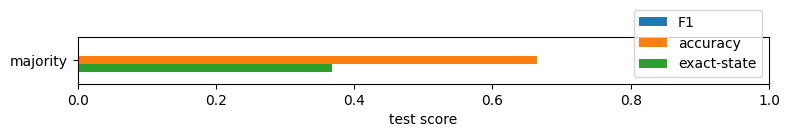

In [4]:
ax = summary[["F1", "accuracy", "exact-state"]].plot.barh(figsize=(8, 0.6 + 0.6 * len(summary)))
ax.set_xlim(0, 1); ax.invert_yaxis(); ax.set_xlabel("test score"); ax.legend(loc="lower right")
plt.tight_layout()

## Majority baseline

Ignores the input and predicts each leg's most frequent training label. For every leg that is
"no contact", so the model always says *all four feet in the air*.

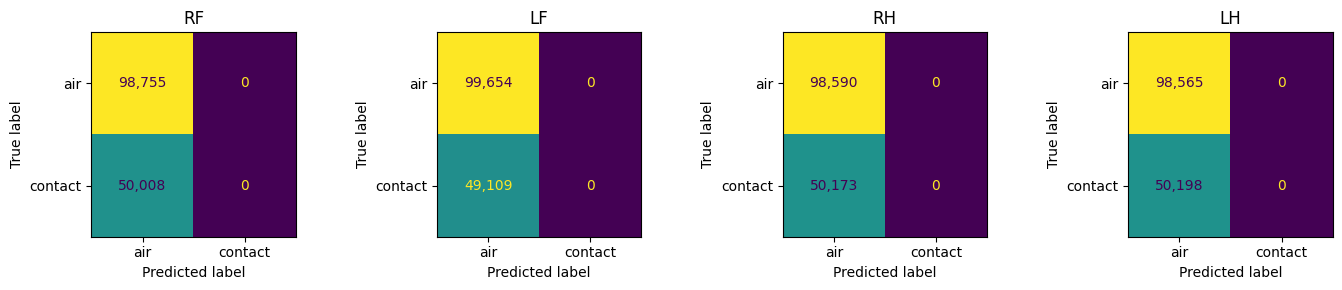

In [5]:
recs = load_recordings()
y_test = labels(recs, split(recs)["test"])
p_test = np.zeros_like(y_test)  # what the majority baseline predicts

fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for k, (ax, leg) in enumerate(zip(axes, LEGS)):
    ConfusionMatrixDisplay.from_predictions(y_test[:, k], p_test[:, k], display_labels=["air", "contact"],
                                            ax=ax, colorbar=False, values_format=",")
    ax.set_title(leg)
plt.tight_layout()

Every contact is missed (bottom row) and nothing is ever predicted as contact (right column is empty):
- **precision** = TP / (TP + FP) = 0/0 → reported as 0, **recall** = TP / (TP + FN) = 0, so **F1 = 0**;
- **accuracy** = (TP + TN) / all ≈ 0.665 — two thirds "right" with no information at all.

That is why F1 on the contact class is the main metric: a model only scores if it actually finds contacts.

In [6]:
print("share of test timesteps with all four feet in the air:", np.mean(y_test.sum(1) == 0).round(4))
print("baseline exact-state accuracy:                        ", round(runs["majority"]["test"]["exact"], 4))

share of test timesteps with all four feet in the air: 0.3679
baseline exact-state accuracy:                         0.3679


Exact-state accuracy 0.368 is just how often *all* feet are in the air in the test blocks (air recordings
and the flight phases of the trot). This is the zero point every model below must clearly beat.